<a href="https://colab.research.google.com/github/AbnerJSV/THE_CORE_Trabajos_iA/blob/main/Telemetria_Videojuegos/practica_mineria_videojuegos_alumnos_guiada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica guiada de Minería de Datos para Ingeniería de Videojuegos

## Caso práctico
Trabajas en el equipo de **Game Analytics** de un estudio que gestiona un videojuego online multijugador.
Dispones de un dataset con telemetría agregada de jugadores y debes analizarlo para encontrar patrones de comportamiento y construir un modelo sencillo de **churn**.

## Qué se trabaja en esta práctica
- Comprensión del problema
- Calidad de datos
- Limpieza y transformación
- Exploración visual
- Reducción de dimensionalidad con **PCA**
- Modelo base de clasificación

## Instrucciones
- En algunas celdas ya tienes parte del código hecha.
- Tendrás que completar las zonas marcadas con `# TODO`.
- No se trata solo de ejecutar: **interpreta** lo que ves.


## 1. Importación de librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns # TODO: importa seaborn con el alias habitual

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.figure(figsize=(8,5))
pd.set_option('display.max_columns', None)


<Figure size 800x500 with 0 Axes>

## 2. Carga del dataset

In [4]:

# El archivo debe estar en la misma carpeta que este notebook.

ruta = 'videojuegos_online_telemetria.csv'

# TODO: carga el CSV en un DataFrame llamado df
df = pd.read_csv(ruta)

# TODO: muestra las 5 primeras filas
df.head()

,PlayerID,Age,Region,Platform,PreferredGenre,SessionsPerWeek,AvgSessionMinutes,DaysSinceLastLogin,PlayerLevel,MatchesPlayedLast30D,WinRate,InGamePurchase,FriendsInGame,UsesVoiceChat,AchievementsUnlocked,ReportsReceivedLast30D,Churn30D
0,P0001,22.0,LATAM,PC,RPG,3,87.0,11,59,14,0.481,7.38,3.0,1,17,0,0
1,P0002,21.0,EU,PC,Shooter,7,113.0,0,45,24,0.475,11.56,8.0,1,21,2,0
2,P0003,40.0,LATAM,Mobile,Shooter,3,67.0,3,68,27,0.341,0.42,6.0,1,26,1,0
3,P0004,37.0,NaN,PC,Shooter,0,48.0,9,40,39,0.225,8.83,NaN,1,41,2,0
4,P0005,28.0,EU,Console,Shooter,3,90.0,15,51,15,0.454,23.86,0.0,0,35,1,1


### Preguntas rápidas
1. ¿Qué representa cada fila?
   -  Un jugador
2. ¿Qué variable parece ser la variable objetivo?
   -  Churn30D
3. ¿Qué decisiones de producto o diseño podría apoyar este análisis?
    - Reducción de Churn



## 3. Comprensión inicial del dataset

In [5]:
print('Dimensiones del dataset:', df.shape)
print('\nTipos de datos:')
display(df.dtypes)

print('\nResumen estadístico de variables numéricas:')
display(df.describe())


Dimensiones del dataset: (558, 17)

Tipos de datos:


,0
PlayerID,object
Age,float64
Region,object
Platform,object
PreferredGenre,object
SessionsPerWeek,int64
AvgSessionMinutes,float64
DaysSinceLastLogin,int64
PlayerLevel,int64
MatchesPlayedLast30D,int64



Resumen estadístico de variables numéricas:


,Age,SessionsPerWeek,AvgSessionMinutes,DaysSinceLastLogin,PlayerLevel,MatchesPlayedLast30D,WinRate,InGamePurchase,FriendsInGame,UsesVoiceChat,AchievementsUnlocked,ReportsReceivedLast30D,Churn30D
count,546.000000,558.000000,546.000000,558.000000,558.000000,558.000000,546.000000,546.000000,546.000000,558.000000,558.000000,558.000000,558.000000
mean,27.893773,4.500000,78.578755,7.646953,35.127240,27.048387,0.512256,14.318462,7.569597,0.546595,22.206093,1.080645,0.408602
std,7.256991,1.909769,41.368230,5.911898,17.631983,14.633996,0.155886,47.664126,4.732448,0.498271,11.713309,1.083060,0.492017
min,16.000000,0.000000,10.000000,0.000000,1.000000,0.000000,0.123000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,21.000000,3.000000,60.000000,3.000000,23.000000,17.000000,0.409000,3.252500,4.000000,0.000000,14.000000,0.000000,0.000000
50%,28.000000,4.000000,76.000000,7.000000,36.000000,27.000000,0.512500,8.050000,7.000000,1.000000,22.000000,1.000000,0.000000
75%,34.000000,6.000000,93.000000,11.000000,47.000000,37.000000,0.619000,16.750000,11.000000,1.000000,30.000000,2.000000,1.000000
max,40.000000,10.000000,600.000000,26.000000,86.000000,69.000000,0.950000,999.000000,25.000000,1.000000,61.000000,5.000000,1.000000


In [6]:
# TODO: muestra cuántos jugadores hay por plataforma
# Pista: value_counts()
print('Jugadores por Plataforma:')
print(df['Platform'].value_counts())


# TODO: muestra cuántos jugadores hay por región
print('\nJugadores por Región:')
print(df['Region'].value_counts())

Jugadores por Plataforma:
Platform
PC         227
Console    159
Mobile     104
pc          68
Name: count, dtype: int64

Jugadores por Región:
Region
EU        216
APAC       81
LATAM      77
Europe     54
Name: count, dtype: int64


## 4. Calidad del dato

In [7]:
print('Valores nulos por columna:')
display(df.isna().sum().sort_values(ascending=False))

print('Filas duplicadas:', df.duplicated().sum())


Valores nulos por columna:


,0
Region,130
InGamePurchase,12
Age,12
AvgSessionMinutes,12
WinRate,12
FriendsInGame,12
PlayerID,0
PreferredGenre,0
Platform,0
PlayerLevel,0


Filas duplicadas: 8


In [8]:
print('Valores únicos de Region:')
print(df['Region'].unique())

print('\nValores únicos de Platform:')
print(df['Platform'].unique())


Valores únicos de Region:
['LATAM' 'EU' nan 'APAC' 'Europe']

Valores únicos de Platform:
['PC' 'Mobile' 'Console' 'pc']


### Pregunta
¿Detectas inconsistencias en variables categóricas? Escríbelas aquí:

- EU y Europe
- PC y pc
- NA(Nort America) y nan


## 5. Limpieza de datos

In [9]:
df_clean = df.copy()

# Eliminamos duplicados
df_clean = df_clean.drop_duplicates(subset=['PlayerID'], keep='first')

# Corrige categorías inconsistentes
# Ejemplos esperados:
# - 'pc' debe pasar a 'PC'
# - 'Europe' debe pasar a 'EU'
df_clean['Platform'] = df_clean['Platform'].replace('pc', 'PC')
df_clean['Region'] = df_clean['Region'].replace('Europe', 'EU')
df_clean['Region'] = df_clean['Region'].fillna('USA')

print(df_clean.shape)

(550, 17)


In [10]:
# Imputación sencilla de nulos en variables numéricas con la mediana
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# TODO: comprueba que ya no queden nulos
print('Valores nulos después de la imputación:')
display(df_clean.isna().sum())

Valores nulos después de la imputación:


,0
PlayerID,0
Age,0
Region,0
Platform,0
PreferredGenre,0
SessionsPerWeek,0
AvgSessionMinutes,0
DaysSinceLastLogin,0
PlayerLevel,0
MatchesPlayedLast30D,0


### Reflexión
¿Por qué tiene sentido usar la **mediana** en vez de la media en algunas variables de telemetría?
  - la media es susceptible a cambios con los outliers y la mediana nop

## 6. Exploración visual

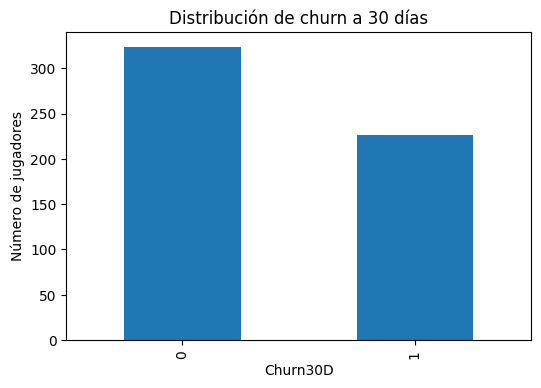

In [11]:
plt.figure(figsize=(6,4))
df_clean['Churn30D'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribución de churn a 30 días')
plt.xlabel('Churn30D')
plt.ylabel('Número de jugadores')
plt.show()


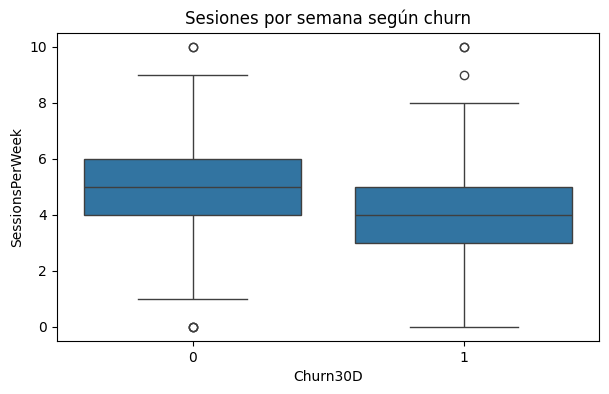

In [13]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df_clean, x='Churn30D', y='SessionsPerWeek')

plt.title('Sesiones por semana según churn')
plt.show()

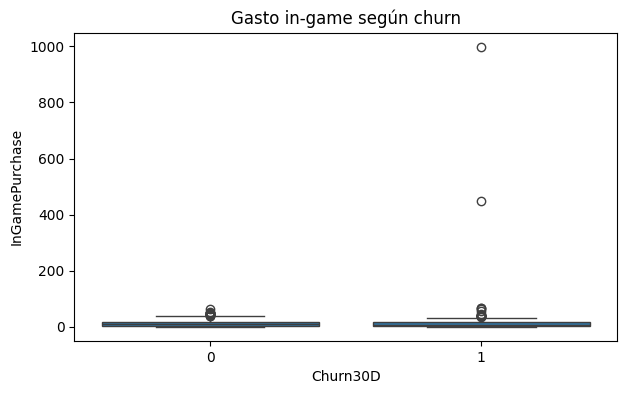

In [14]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df_clean, x='Churn30D', y='InGamePurchase')
plt.title('Gasto in-game según churn')
plt.show()


In [15]:
# TODO: calcula el churn medio por plataforma
# Pista: groupby + mean
churn_medio_por_plataforma = df_clean.groupby('Platform')['Churn30D'].mean()
print('Churn medio por plataforma:')
print(churn_medio_por_plataforma)

Churn medio por plataforma:
Platform
Console    0.474684
Mobile     0.394231
PC         0.381944
Name: Churn30D, dtype: float64


### Preguntas de interpretación
1. ¿Los jugadores con menos sesiones parecen abandonar más?
    - SI
2. ¿Parece existir relación entre gasto y retención?
    - NO
3. ¿Ves alguna señal útil para un equipo de LiveOps?
    - NO

## 7. Preparación para modelado

In [16]:
y = df_clean['Churn30D']

# Quitamos la variable objetivo y el identificador
X = df_clean.drop(columns=['Churn30D', 'PlayerID'])

# Convertimos variables categóricas a numéricas
X = pd.get_dummies(X, drop_first=True)

print('Dimensiones de X:', X.shape)
display(X.head())


Dimensiones de X: (550, 22)


,Age,SessionsPerWeek,AvgSessionMinutes,DaysSinceLastLogin,PlayerLevel,MatchesPlayedLast30D,WinRate,InGamePurchase,FriendsInGame,UsesVoiceChat,AchievementsUnlocked,ReportsReceivedLast30D,Region_EU,Region_LATAM,Region_USA,Platform_Mobile,Platform_PC,PreferredGenre_MOBA,PreferredGenre_RPG,PreferredGenre_Shooter,PreferredGenre_Sports,PreferredGenre_Strategy
0,22.0,3,87.0,11,59,14,0.481,7.38,3.0,1,17,0,False,True,False,False,True,False,True,False,False,False
1,21.0,7,113.0,0,45,24,0.475,11.56,8.0,1,21,2,True,False,False,False,True,False,False,True,False,False
2,40.0,3,67.0,3,68,27,0.341,0.42,6.0,1,26,1,False,True,False,True,False,False,False,True,False,False
3,37.0,0,48.0,9,40,39,0.225,8.83,7.0,1,41,2,False,False,True,False,True,False,False,True,False,False
4,28.0,3,90.0,15,51,15,0.454,23.86,0.0,0,35,1,True,False,False,False,False,False,False,True,False,False


## 8. Estandarización y PCA

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

var_exp = pca_full.explained_variance_ratio_
var_exp_acum = np.cumsum(var_exp)

display(var_exp[:10])
display(var_exp_acum[:10])


array([0.07583505, 0.07379745, 0.06167712, 0.06147012, 0.05895212,
       0.05803313, 0.0544838 , 0.0517818 , 0.05021249, 0.04870255])

array([0.07583505, 0.1496325 , 0.21130962, 0.27277973, 0.33173186,
       0.38976499, 0.44424879, 0.49603059, 0.54624308, 0.59494564])

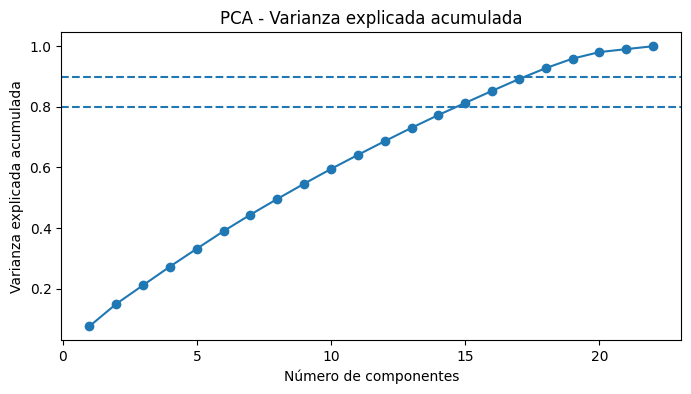

In [18]:
plt.figure(figsize=(8,4))
plt.plot(range(1, len(var_exp_acum)+1), var_exp_acum, marker='o')
plt.axhline(y=0.80, linestyle='--')
plt.axhline(y=0.90, linestyle='--')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA - Varianza explicada acumulada')
plt.show()


In [19]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Churn30D'] = y.reset_index(drop=True)

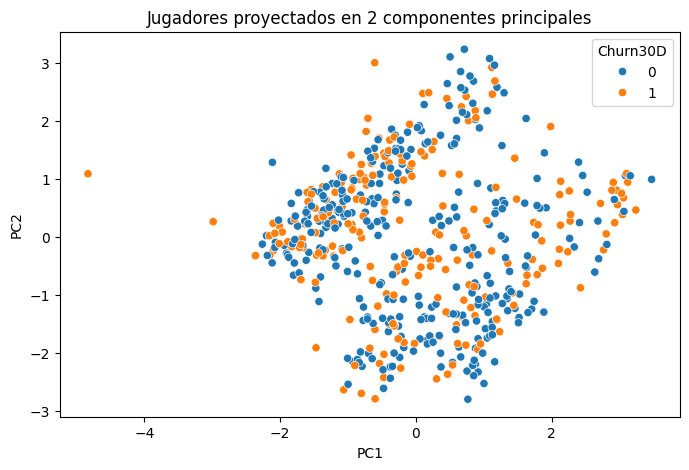

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Churn30D')

plt.title('Jugadores proyectados en 2 componentes principales')
plt.show()

### Preguntas de interpretación
1. ¿Se aprecia alguna separación visual entre perfiles?
- NO
2. ¿Qué ventaja aporta PCA en un problema con muchas variables?
- Reduce la dimensionalidad, eliminando el ruido y la redundancia
3. ¿Qué inconveniente tiene usar PCA desde el punto de vista de interpretabilidad?
- Se pierde la relación directa con el negocio.


## 9. Modelo base de clasificación

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)


(412, 22) (138, 22)


In [22]:
modelo = LogisticRegression(max_iter=2000)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)


In [23]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification report:\n')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print('Matriz de confusión:')
print(cm)


Accuracy: 0.6231884057971014

Classification report:

              precision    recall  f1-score   support

           0       0.64      0.83      0.72        81
           1       0.58      0.33      0.42        57

    accuracy                           0.62       138
   macro avg       0.61      0.58      0.57       138
weighted avg       0.61      0.62      0.60       138

Matriz de confusión:
[[67 14]
 [38 19]]


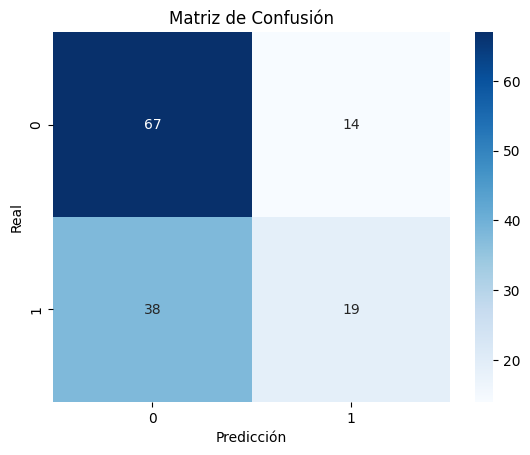

In [24]:
# TODO: representa la matriz de confusión con un heatmap
# Pista: sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

## 10. Conclusiones finales

Responde brevemente:

1. ¿Qué variables parecen más relacionadas con el churn?
- el tiempo de juego diario (decreciente), el número de sesiones, el nivel alcanzado y el tiempo desde la última compra. Un descenso brusco en estos valores es un predictor clave.
2. ¿Qué acciones propondrías al equipo de diseño, retención o monetización?
- Lanzar campañas de "reenganche" (regalos o notificaciones) para los 19 identificados correctamente.
- Revisar el balanceo del juego en los puntos donde los jugadores empiezan a mostrar patrones de abandono
- Evitar saturar con ofertas a los jugadores con bajo riesgo para no cansar la experiencia de usuario.
3. ¿Qué has aprendido sobre preparación de datos y PCA en un contexto de videojuegos?
- Es vital para manejar decenas de métricas de telemetría, pero la pérdida de interpretabilidad dificulta explicarle al equipo de diseño exactamente por qué un jugador se va.
